# Лабораторная 6. Свёрточные нейронные сети. Классификация изображений

**Задание.** Реализовать свёрточную сеть со свёрточными блоками двух видов:
а) `{Conv2d-ReLU-MaxPool}`; б) `{Conv2d-ReLU-Conv2d-ReLU-MaxPool}`.

Для выборки MNIST или FashionMNIST, или одной из выборок модуля `Datasets`
выбрать сочетание *некоторых* из следующих гиперпараметров, дающих наилучшее
качество классификации: 1) коэффициент обучения; 2) тип свёрточных блоков
(типы а или б) и их количество; 3) параметры свёртки (класс `Conv2d`):
размер фильтра `kernel_size` и шаг `stride`; 4) параметры пуллинга (класс
`MaxPool2d`): размер окна `kernel_size` и шаг `stride`.

Оценить количество эпох, достаточное для классификации с точностью (метрика
accuracy) не меньшей 90% для свёрточной сети с выбранным сочетанием указанных
параметров.

Дополнительно (по выбору): варьирование параметров обучения, других
гиперпараметров модели, использование различных оптимизаторов.

## 1. Теория

### Данные

MNIST, изображения $28 \times 28$ в градациях серого, 10 классов. Из обучающей
части MNIST берутся три непересекающиеся подвыборки: 3000 изображений для
обучения при переборе гиперпараметров, 1500 отложенных для их оценки и 12000 для
обучения финальной модели. Финальная модель проверяется на тестовой выборке MNIST
из 10000 изображений, которая в переборе не участвует. Яркости делятся на 255 и нормируются стандартными для MNIST значениями
$\mu = 0.1307$, $\sigma = 0.3081$.

### Свёртка

Свёртка применяет одно и то же ядро $K$ размера $k \times k$ ко всем положениям
изображения:

$$(X * K)_{ij} = \sum_{u=0}^{k-1}\sum_{v=0}^{k-1} X_{\,i s + u,\; j s + v}\,K_{uv},$$

где $s$ это шаг (`stride`). Число параметров свёрточного слоя равно
$k^2 c_{\text{in}} c_{\text{out}} + c_{\text{out}}$, где $c_{\text{in}}$ и
$c_{\text{out}}$ это числа входных и выходных каналов, и от размера изображения
не зависит.

### Размер выхода

Для входа $n \times n$, ядра $k$, шага $s$ и дополнения $p$

$$n_{\text{out}} = \left\lfloor \frac{n + 2p - k}{s} \right\rfloor + 1 .$$

В свёртках берётся $p = \lfloor k/2 \rfloor$, тогда при $s = 1$ размер карты не
меняется. Той же формуле подчиняется пуллинг: `MaxPool2d` берёт максимум по окну
$k \times k$ с шагом $s$.

### Функция потерь

Перекрёстная энтропия $L = -\frac1n\sum_k \log p_{y_k}(x_k)$, где $p$ это
мягкий максимум выходов сети.

### Что перебирается

| Гиперпараметр | Значения |
|---|---|
| коэффициент обучения | $0.005$, $0.01$, $0.05$, $0.1$ |
| тип блока | а) Conv-ReLU-Pool; б) Conv-ReLU-Conv-ReLU-Pool |
| число блоков | 1, 2 |
| `kernel_size` свёртки | 3, 5, 7 |
| `stride` свёртки | 1, 2 |
| `kernel_size` пуллинга | 2, 3 |
| `stride` пуллинга | 2, 3 |
| оптимизатор | SGD с моментом, Adam |

Перебор в два этапа: сначала основная сетка по первым четырём параметрам, затем
параметры свёртки, пуллинга и оптимизатор на лучшей найденной конфигурации. На
сетке каждая конфигурация обучается 6 эпох батчами по 64, финальная модель 12
эпох.

### Мера качества

Доля верных ответов $\mathrm{accuracy} = \frac1n \sum_k [\,\hat y_k = y_k\,]$.

## 2. Данные

In [1]:
import os
import struct
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

torch.manual_seed(20260905)
torch.backends.cudnn.deterministic = True  # одинаковые числа при перезапуске на GPU
RNG = np.random.default_rng(20260905)
plt.rcParams['figure.dpi'] = 110

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'torch {torch.__version__}, устройство: {DEVICE}')

torch 2.11.0+cu128, устройство: cuda


In [2]:
def read_idx(path):
    with open(path, 'rb') as f:
        magic, = struct.unpack('>I', f.read(4))
        dims = struct.unpack('>' + 'I' * (magic & 0xff), f.read(4 * (magic & 0xff)))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(dims)


def mnist_dir():
    for c in [os.environ.get('MNIST_DIR'),
              '../../bachelor/Perceptron/data_generation/MNIST/raw',
              'data/MNIST/raw']:
        if c and Path(c, 'train-images-idx3-ubyte').exists():
            return Path(c)
    raise FileNotFoundError('не найдены файлы MNIST')


D = mnist_dir()
Xtr_all = read_idx(D / 'train-images-idx3-ubyte')
ytr_all = read_idx(D / 'train-labels-idx1-ubyte')
Xte_all = read_idx(D / 't10k-images-idx3-ubyte')
yte_all = read_idx(D / 't10k-labels-idx1-ubyte')

MEAN, STD = 0.1307, 0.3081


def to_tensor(X, y):
    """Изображения в тензор (N, 1, 28, 28) с нормировкой, метки в long."""
    xt = torch.tensor(X, dtype=torch.float32).unsqueeze(1) / 255.0  # ось 1 это канал
    xt = (xt - MEAN) / STD
    # .to(DEVICE) переносит тензоры на видеокарту, если она есть
    return xt.to(DEVICE), torch.tensor(y, dtype=torch.long).to(DEVICE)


# три непересекающиеся части обучающей выборки: перебор, отложенная, финальная модель
perm = RNG.permutation(len(Xtr_all))
idx_grid, idx_val, idx_big = perm[:3000], perm[3000:4500], perm[4500:16500]
Xg, yg = to_tensor(Xtr_all[idx_grid], ytr_all[idx_grid])
Xv, yv = to_tensor(Xtr_all[idx_val], ytr_all[idx_val])
print(f'перебор гиперпараметров: обучающая {tuple(Xg.shape)}, отложенная {tuple(Xv.shape)}')

перебор гиперпараметров: обучающая (3000, 1, 28, 28), отложенная (1500, 1, 28, 28)


## 3. Архитектура и обучение

In [3]:
class ConvNet(nn.Module):
    """Свёрточная сеть из блоков двух видов.
    block='a': Conv-ReLU-MaxPool; block='b': Conv-ReLU-Conv-ReLU-MaxPool."""

    def __init__(self, block='a', n_blocks=2, ks=3, stride=1,
                 pool_k=2, pool_s=2, channels=8):
        super().__init__()
        layers, c_in, size = [], 1, 28  # size это текущий размер карты признаков
        for i in range(n_blocks):
            c_out = channels * (i + 1)
            pad = ks // 2
            layers += [nn.Conv2d(c_in, c_out, ks, stride, pad), nn.ReLU()]
            size = (size + 2 * pad - ks) // stride + 1  # формула размера выхода
            if block == 'b':
                layers += [nn.Conv2d(c_out, c_out, ks, 1, pad), nn.ReLU()]
            if size >= pool_k:  # пуллинг возможен, пока карта не меньше окна
                layers += [nn.MaxPool2d(pool_k, pool_s)]
                size = (size - pool_k) // pool_s + 1
            c_in = c_out
        self.features = nn.Sequential(*layers)  # слои применяются по порядку
        self.out_size = size
        self.classifier = nn.Linear(c_in * size * size, 10)

    def forward(self, x):
        # flatten(1) вытягивает карту признаков в вектор, сохраняя ось объектов
        return self.classifier(self.features(x).flatten(1))

In [4]:
def evaluate(model, X, y, batch=512):
    """Доля верных ответов, считается батчами."""
    model.eval()
    correct = 0
    with torch.no_grad():  # при оценке градиенты не нужны
        for s in range(0, len(X), batch):
            correct += (model(X[s:s + batch]).argmax(1) == y[s:s + batch]).sum().item()
    return correct / len(X)


def train_model(model, Xtr, ytr, Xval, yval, lr, epochs, optimizer='sgd', batch=64, seed=0):
    """Обучение с записью accuracy на выборке Xval после каждой эпохи."""
    torch.manual_seed(seed)
    if optimizer == 'sgd':
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    else:
        opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.CrossEntropyLoss()
    hist = []
    for _ in range(epochs):
        model.train()
        perm = torch.randperm(len(Xtr), device=Xtr.device)  # новый порядок объектов
        for s in range(0, len(Xtr), batch):
            b = perm[s:s + batch]
            opt.zero_grad()  # обнуление градиентов прошлого шага
            lossf(model(Xtr[b]), ytr[b]).backward()  # градиенты функции потерь по весам
            opt.step()  # шаг оптимизатора
        hist.append(evaluate(model, Xval, yval))
    return np.array(hist)


def epochs_to_level(hist, level=0.90):
    """Номер первой эпохи, на которой accuracy достигла level, иначе None."""
    for i, acc in enumerate(hist, start=1):
        if acc >= level:
            return i
    return None

In [5]:
demo = ConvNet(block='b', n_blocks=2, ks=3)
print(demo)
print(f'\nразмер карты признаков перед классификатором: '
      f'{demo.out_size} x {demo.out_size}')
print(f'число параметров: {sum(p.numel() for p in demo.parameters()):,}')

ConvNet(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=784, out_features=10, bias=True)
)

размер карты признаков перед классификатором: 7 x 7
число параметров: 12,002


## 4. Основная сетка гиперпараметров

In [6]:
EPOCHS = 6
rows = []
# itertools.product перебирает все сочетания значений из четырёх списков
for lr, block, n_blocks, ks in itertools.product(
        [0.005, 0.01, 0.05, 0.1], ['a', 'b'], [1, 2], [3, 5, 7]):
    torch.manual_seed(20260905)
    model = ConvNet(block=block, n_blocks=n_blocks, ks=ks).to(DEVICE)  # веса на видеокарту
    hist = train_model(model, Xg, yg, Xv, yv, lr=lr, epochs=EPOCHS)
    rows.append(dict(stage='основная', lr=lr, block=block, n_blocks=n_blocks,
                     ks=ks, stride=1, pool_k=2, pool_s=2, optimizer='sgd',
                     best_acc=float(hist.max()), last_acc=float(hist[-1]),
                     epochs_to_90=epochs_to_level(hist),
                     params=sum(p.numel() for p in model.parameters()),
                     curve=list(np.round(hist, 4))))

grid1 = pd.DataFrame(rows)
top = grid1.sort_values('best_acc', ascending=False).head(10)
print(top[['lr', 'block', 'n_blocks', 'ks', 'best_acc', 'epochs_to_90', 'params']]
      .round(4).to_string(index=False, formatters={'epochs_to_90': '{:.0f}'.format}))

   lr block  n_blocks  ks  best_acc epochs_to_90  params
0.010     a         2   5    0.9693            1   11274
0.050     a         2   3    0.9687            1    9098
0.010     a         2   7    0.9680            2   14538
0.050     a         2   5    0.9680            1   11274
0.010     b         2   5    0.9647            3   19298
0.050     a         1   7    0.9640            1   16090
0.010     b         2   3    0.9607            3   12002
0.005     a         2   7    0.9600            2   14538
0.010     b         1   5    0.9600            2   17506
0.050     a         1   5    0.9600            1   15898


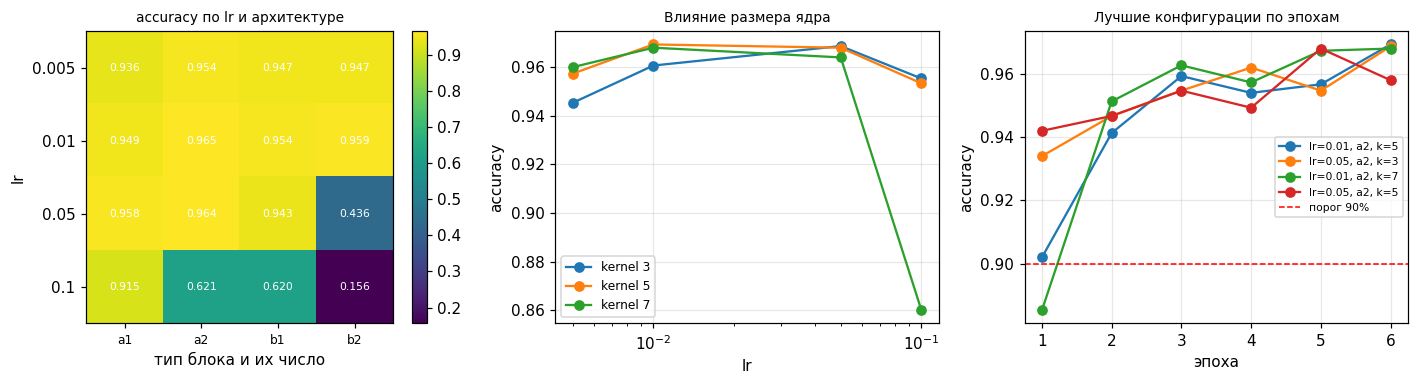

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
piv = grid1.pivot_table(index='lr', columns=['block', 'n_blocks'], values='best_acc')
im = axes[0].imshow(piv.values, cmap='viridis', aspect='auto')
axes[0].set_xticks(range(len(piv.columns)))
axes[0].set_xticklabels([f'{b}{n}' for b, n in piv.columns], fontsize=8)
axes[0].set_yticks(range(len(piv.index))); axes[0].set_yticklabels(piv.index)
axes[0].set_xlabel('тип блока и их число'); axes[0].set_ylabel('lr')
axes[0].set_title('accuracy по lr и архитектуре', fontsize=9)
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        axes[0].text(j, i, f'{piv.values[i, j]:.3f}', ha='center', va='center',
                     fontsize=7, color='white')
plt.colorbar(im, ax=axes[0])

for ks in [3, 5, 7]:
    s = grid1[grid1.ks == ks].groupby('lr')['best_acc'].max()
    axes[1].plot(s.index, s.values, marker='o', label=f'kernel {ks}')
axes[1].set_xscale('log'); axes[1].set_xlabel('lr'); axes[1].set_ylabel('accuracy')
axes[1].set_title('Влияние размера ядра', fontsize=9)
axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)

for _, r in grid1.sort_values('best_acc', ascending=False).head(4).iterrows():
    axes[2].plot(range(1, EPOCHS + 1), r['curve'], marker='o',
                 label=f"lr={r['lr']}, {r['block']}{r['n_blocks']}, k={r['ks']}")
axes[2].axhline(0.90, color='red', ls='--', lw=1, label='порог 90%')
axes[2].set_xlabel('эпоха'); axes[2].set_ylabel('accuracy')
axes[2].set_title('Лучшие конфигурации по эпохам', fontsize=9)
axes[2].grid(alpha=0.3); axes[2].legend(fontsize=7)
plt.tight_layout()
plt.show()

## 5. Параметры свёртки, пуллинга и оптимизатор

In [8]:
best1 = grid1.sort_values('best_acc', ascending=False).iloc[0]
print(f'лучшая конфигурация основной сетки: lr={best1["lr"]}, блок {best1["block"]}, '
      f'блоков {best1["n_blocks"]}, kernel {best1["ks"]}, accuracy {best1["best_acc"]:.4f}')

rows = []
for stride, pool_k, pool_s in itertools.product([1, 2], [2, 3], [2, 3]):
    torch.manual_seed(20260905)
    model = ConvNet(block=best1['block'], n_blocks=int(best1['n_blocks']),
                    ks=int(best1['ks']), stride=stride, pool_k=pool_k,
                    pool_s=pool_s).to(DEVICE)
    hist = train_model(model, Xg, yg, Xv, yv, lr=float(best1['lr']), epochs=EPOCHS)
    rows.append(dict(stage='свёртка и пуллинг', lr=best1['lr'], block=best1['block'],
                     n_blocks=best1['n_blocks'], ks=best1['ks'], stride=stride,
                     pool_k=pool_k, pool_s=pool_s, optimizer='sgd',
                     best_acc=float(hist.max()), last_acc=float(hist[-1]),
                     epochs_to_90=epochs_to_level(hist),
                     params=sum(p.numel() for p in model.parameters()),
                     curve=list(np.round(hist, 4))))

for opt_name, lr in [('adam', 0.001), ('adam', 0.003), ('sgd', float(best1['lr']))]:
    torch.manual_seed(20260905)
    model = ConvNet(block=best1['block'], n_blocks=int(best1['n_blocks']),
                    ks=int(best1['ks'])).to(DEVICE)
    hist = train_model(model, Xg, yg, Xv, yv, lr=lr, epochs=EPOCHS, optimizer=opt_name)
    rows.append(dict(stage='оптимизатор', lr=lr, block=best1['block'],
                     n_blocks=best1['n_blocks'], ks=best1['ks'], stride=1,
                     pool_k=2, pool_s=2, optimizer=opt_name,
                     best_acc=float(hist.max()), last_acc=float(hist[-1]),
                     epochs_to_90=epochs_to_level(hist),
                     params=sum(p.numel() for p in model.parameters()),
                     curve=list(np.round(hist, 4))))

grid2 = pd.DataFrame(rows)
print(grid2[['stage', 'stride', 'pool_k', 'pool_s', 'optimizer', 'lr',
             'best_acc', 'epochs_to_90', 'params']].round(4)
      .to_string(index=False, formatters={'epochs_to_90': '{:.0f}'.format}))

лучшая конфигурация основной сетки: lr=0.01, блок a, блоков 2, kernel 5, accuracy 0.9693


            stage  stride  pool_k  pool_s optimizer    lr  best_acc epochs_to_90  params
свёртка и пуллинг       1       2       2       sgd 0.010    0.9693            1   11274
свёртка и пуллинг       1       2       3       sgd 0.010    0.9453            3    4874
свёртка и пуллинг       1       3       2       sgd 0.010    0.9773            1    9194
свёртка и пуллинг       1       3       3       sgd 0.010    0.9640            2    4874
свёртка и пуллинг       2       2       2       sgd 0.010    0.9367            3    4074
свёртка и пуллинг       2       2       3       sgd 0.010    0.8933          NaN    3594
свёртка и пуллинг       2       3       2       sgd 0.010    0.9473            5    3594
свёртка и пуллинг       2       3       3       sgd 0.010    0.9453            3    4074
      оптимизатор       1       2       2      adam 0.001    0.9573            2   11274
      оптимизатор       1       2       2      adam 0.003    0.9707            1   11274
      оптимизатор    

In [9]:
allres = pd.concat([grid1, grid2], ignore_index=True)
allres.drop(columns='curve').to_csv('results.csv', index=False)

## 6. Число эпох до точности 90%

In [10]:
sub = allres.dropna(subset=['epochs_to_90'])
print(f'достигли 90%: {len(sub)} из {len(allres)} конфигураций')
print('\nраспределение числа эпох до 90%:')
print(sub.epochs_to_90.astype(int).value_counts().sort_index().to_string())
print(f'\nсреди тех, кто дошёл: медиана {sub.epochs_to_90.median():.0f} эпох, '
      f'минимум {sub.epochs_to_90.min():.0f}, максимум {sub.epochs_to_90.max():.0f}')
print(f'\nконфигурации, не достигшие 90% за {EPOCHS} эпох:')
print(allres[allres.epochs_to_90.isna()][
    ['lr', 'block', 'n_blocks', 'ks', 'stride', 'pool_k', 'pool_s',
     'optimizer', 'best_acc']].round(4).to_string(index=False))

достигли 90%: 47 из 59 конфигураций

распределение числа эпох до 90%:
epochs_to_90
1    13
2    18
3    12
4     1
5     3

среди тех, кто дошёл: медиана 2 эпох, минимум 1, максимум 5

конфигурации, не достигшие 90% за 6 эпох:
  lr block  n_blocks  ks  stride  pool_k  pool_s optimizer  best_acc
0.05     b         2   3       1       2       2       sgd    0.2853
0.05     b         2   7       1       2       2       sgd    0.1153
0.10     a         1   7       1       2       2       sgd    0.8600
0.10     a         2   5       1       2       2       sgd    0.7913
0.10     a         2   7       1       2       2       sgd    0.1153
0.10     b         1   3       1       2       2       sgd    0.8873
0.10     b         1   5       1       2       2       sgd    0.8580
0.10     b         1   7       1       2       2       sgd    0.1153
0.10     b         2   3       1       2       2       sgd    0.1153
0.10     b         2   5       1       2       2       sgd    0.1153
0.10     b    

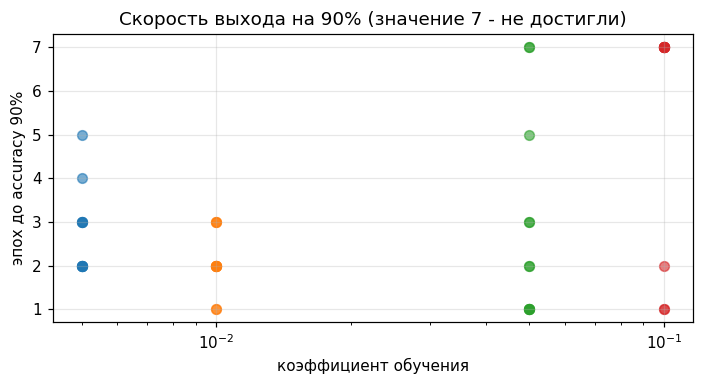

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for lr in sorted(grid1.lr.unique()):
    s = grid1[grid1.lr == lr]
    ax.scatter([lr] * len(s), s.epochs_to_90.fillna(EPOCHS + 1), alpha=0.6, s=40)
ax.set_xscale('log'); ax.set_xlabel('коэффициент обучения')
ax.set_ylabel('эпох до accuracy 90%')
ax.set_title(f'Скорость выхода на 90% (значение {EPOCHS + 1} - не достигли)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Финальная модель

In [12]:
best = allres.sort_values('best_acc', ascending=False).iloc[0]
print('лучшее сочетание гиперпараметров:')
for k in ['lr', 'block', 'n_blocks', 'ks', 'stride', 'pool_k', 'pool_s', 'optimizer']:
    print(f'  {k}: {best[k]}')
print(f'  accuracy на отложенной выборке: {best["best_acc"]:.4f}')

Xb, yb = to_tensor(Xtr_all[idx_big], ytr_all[idx_big])
Xt, yt = to_tensor(Xte_all, yte_all)

torch.manual_seed(20260905)
final = ConvNet(block=best['block'], n_blocks=int(best['n_blocks']), ks=int(best['ks']),
                stride=int(best['stride']), pool_k=int(best['pool_k']),
                pool_s=int(best['pool_s'])).to(DEVICE)
hist_final = train_model(final, Xb, yb, Xt, yt, lr=float(best['lr']), epochs=12,
                         optimizer=best['optimizer'])
print(f'\naccuracy на тестовой выборке MNIST (10000) после 12 эпох: {hist_final[-1]:.4f}')
print(f'эпох до 90% на тестовой выборке: {epochs_to_level(hist_final)}')

лучшее сочетание гиперпараметров:
  lr: 0.01
  block: a
  n_blocks: 2
  ks: 5
  stride: 1
  pool_k: 3
  pool_s: 2
  optimizer: sgd
  accuracy на отложенной выборке: 0.9773



accuracy на тестовой выборке MNIST (10000) после 12 эпох: 0.9860
эпох до 90% на тестовой выборке: 1


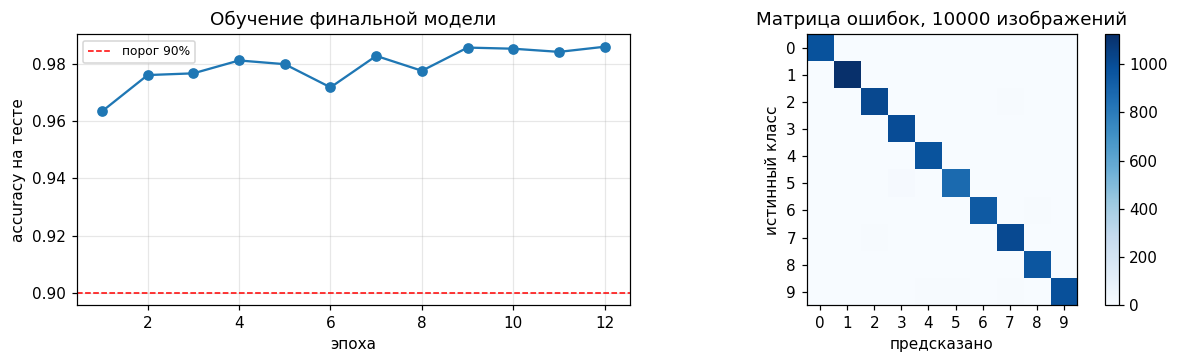

самые частые путаницы:
  5 принята за 3: 11
  7 принята за 2: 7
  9 принята за 7: 6
  2 принята за 7: 6
  9 принята за 5: 5


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(range(1, len(hist_final) + 1), hist_final, marker='o')
axes[0].axhline(0.90, color='red', ls='--', lw=1, label='порог 90%')
axes[0].set_xlabel('эпоха'); axes[0].set_ylabel('accuracy на тесте')
axes[0].set_title('Обучение финальной модели'); axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=8)

final.eval()
with torch.no_grad():  # без подсчёта градиентов, батчами по 512
    pred = torch.cat([final(Xt[s:s + 512]).argmax(1) for s in range(0, len(Xt), 512)])
cm = confusion_matrix(yte_all, pred.cpu().numpy())  # .cpu() забирает тензор с видеокарты
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_title('Матрица ошибок, 10000 изображений')
axes[1].set_xlabel('предсказано'); axes[1].set_ylabel('истинный класс')
axes[1].set_xticks(range(10)); axes[1].set_yticks(range(10))
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

pairs = [(cm[i, j], i, j) for i in range(10) for j in range(10) if i != j]
pairs.sort(reverse=True)
print('самые частые путаницы:')
for n, i, j in pairs[:5]:
    print(f'  {i} принята за {j}: {n}')

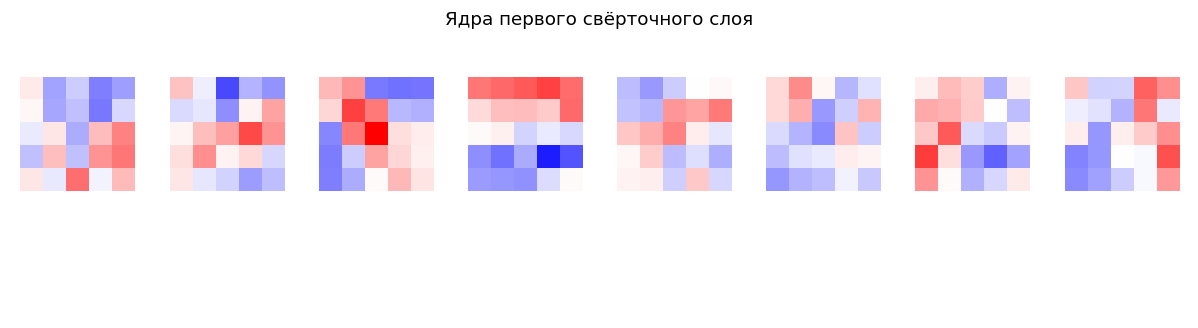

In [14]:
# веса первой свёртки как массив numpy; detach отцепляет их от подсчёта градиентов
w = final.features[0].weight.detach().cpu().numpy()
n = min(len(w), 16)
fig, axes = plt.subplots(2, 8, figsize=(11, 2.8))
for i, ax in enumerate(axes.ravel()):
    ax.axis('off')
    if i < n:
        ax.imshow(w[i, 0], cmap='bwr', vmin=-np.abs(w).max(), vmax=np.abs(w).max())
fig.suptitle('Ядра первого свёрточного слоя', y=1.05)
plt.tight_layout()
plt.show()